In [3]:
# %%
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime
import spectral_connectivity

In [ ]:
from scipy.signal import welch

from sklearn.decomposition import PCA


ptID = 'RCS09'
path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
pt_path = f"/home/rvatsyayan/AnushaData"
electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df.csv")
# data_root = Path(path_string)
# file_keyword = '_meanpsd_clean'
# file_keyword = '_reref'
# dataset_name = "re-referenced" # files with mean power spectral density 
# file_keyword = 'meanpsd_clean'
# dataset_name = 'mean_psd'
srate_new = 1000
freqs_welch = []
freq_range = [3,50]

# electrode_df = pd.read_csv(f"/home/jiahuang/test-code-hazel/{ptID}_new_electrode_property_df.csv")

def idx_to_channel(all_channel_labels,idx):
    match = all_channel_labels[all_channel_labels['edf_ch_idx'] == idx]
    return match['New ROI Label_all channel'].values[0]

# Function to extract numeric part from filename
def extract_number(filename):
    return int(''.join(filter(str.isdigit, filename)))
def man_z_score(array):
        array_mean = np.nanmean(array)
        array_std = np.nanstd(array)
        zscore_array = (array - array_mean)/array_std
        return zscore_array
# split trials
def split_dep(X, percent):
    idx = np.argsort(X)
    x = len(X)
    low, neutral, high = idx[:int(x*percent)], idx[int(x*percent):int(x*(1-percent))],idx[int(x*(1-percent)):]
    return high, neutral, low

def load_h5_file(path_string, pt_path, file_keyword='meanpsd_clean', dataset_name='mean_psd'):
    h5_arrays = []
    fileids = [] 
    # Get list of files in directory and sort them based on numeric part
    files = sorted(os.listdir(path_string), key=extract_number)
    
    for filename in files:
        if filename.endswith(rf'{file_keyword}.h5'):
            filepath = os.path.join(path_string, filename)
            # Load the .h5 file
            with h5py.File(filepath, 'r') as hf:
                # Load the dataset as float32
                dataset = np.array(hf[dataset_name], dtype=np.float32)
                # Append the dataset to the list
                h5_arrays.append(dataset)

    files = sorted(os.listdir(pt_path), key=extract_number)
    for filename in files:
        if filename.endswith('.h5'):
            with h5py.File(os.path.join(pt_path, filename), 'r') as hf:
                # get record_id 
                fileid_pre = (pd.DataFrame(hf['pain_info']).iloc[1,0]).decode('utf-8')
                fileid = datetime.strptime(fileid_pre, '%d-%b-%Y %H:%M:%S')
                fileids.append(fileid)
    fileids = pd.to_datetime(fileids)

    return h5_arrays, fileids

def load_reref_file_welch(path_string, pt_path, ptID, file_keyword='reref', dataset_name='re-referenced'):
    records = []
    # Get list of files in directory and sort them based on numeric part
    files = sorted(os.listdir(path_string), key=extract_number)
    trial_idx = 0

    new_surveys,idx_to_keep,missing_channels = get_missing_trial_and_channel(path_string, pt_path, ptID)
    mask_valid, affective_latent, sensory_latent, onlyhigh_aff, onlyhigh_sens = process_score(path_string,pt_path,ptID)
    new_surveys = new_surveys.loc[mask_valid,:]
    all_channel_labels = get_all_channel_labels(path_string, pt_path, ptID)

    valid_file_indices = np.where(idx_to_keep)[0]
    valid_after_second_filter = valid_file_indices[mask_valid]
    file_to_clean = {file_idx: clean_idx for clean_idx, file_idx in enumerate(valid_after_second_filter)}


    for filename in files:
        if filename.endswith(rf'{file_keyword}.h5'):
        
            if trial_idx not in valid_after_second_filter: 
                trial_idx+=1
                continue 
            clean_idx = file_to_clean[trial_idx]

            filepath = os.path.join(path_string, filename)
            # Load the .h5 file
            with h5py.File(filepath, 'r') as hf:
                # Load the dataset as float32
                dataset = np.array(hf[dataset_name], dtype=np.float32)
                # Append the dataset to the list
                for row in all_channel_labels.itertuples(index=False):
                    fm = FOOOF(peak_width_limits=[1, 8], min_peak_height=0.1, 
                                max_n_peaks=6, verbose=False)
                    
                    ch_name = row.New_ROI_Label_all_channel
                    ch_idx = row.edf_ch_idx
                    freqs_welch, psd_welch = welch(
                        dataset[:,ch_idx], 
                        fs=srate_new,
                        nperseg=4 * srate_new
                    )

                    
                    fm.fit(freqs_welch, psd_welch, freq_range)
                    
                    group = ''
                    if clean_idx in onlyhigh_aff: group = 'only_high_aff'
                    elif clean_idx in onlyhigh_sens: group = 'only_high_sense'

                    # Append the dataset to the list
                    records.append({
                        'trial_idx': trial_idx,
                        'edf_ch_idx': ch_idx,
                        'ch_label': ch_name,
                        'psd_after_welch': psd_welch,
                        'fooof': fm,
                        'affective': affective_latent[clean_idx],
                        'sensory': sensory_latent[clean_idx],
                        'group': group
                    })
                        
                trial_idx+=1

    return pd.DataFrame(records)

def get_missing_trial_and_channel(path_string, pt_path,ptID):
    h5_arrays, fileids = load_h5_file(path_string, pt_path)
    all_data  = []
    all_data = np.stack(h5_arrays, axis=2)
    del h5_arrays

    # %%
    file = f"/home/rvatsyayan/AnushaData/Pain_Scores_{ptID}.xlsx"
    raw_surveys = pd.read_excel(file)
    
    missing_bm_data = np.setdiff1d(raw_surveys.Timestamp, fileids)
    missing_surveys = np.setdiff1d(fileids, raw_surveys.Timestamp)
    missing_channels = [i for i in range(all_data.shape[1]) if np.any(all_data[:,i,:])!=0]
    
    idx_missing_surveys = ~np.isin(fileids, missing_surveys)

    new_alldata = all_data[:,:,idx_missing_surveys]

    idx_missing_neuraldata = ~np.isin(raw_surveys.Timestamp, missing_bm_data)
    new_surveys = raw_surveys.iloc[idx_missing_neuraldata]
    assert(new_surveys.shape[0] == new_alldata.shape[2])

    return new_surveys,idx_missing_surveys,missing_channels

def get_all_channel_labels(path_string, pt_path,ptID):
    new_surveys,idx_to_keep,missing_channels = get_missing_trial_and_channel(path_string,pt_path,ptID)
    electrode_df["edf_ch_idx"] = (
        electrode_df["EDF Channel Number"]
        .astype(str)
        .str.replace(r"[^\d]", "", regex=True)
        .astype(int)
        - 1
    )
    electrode_df_idx = [i for i in range(electrode_df.shape[0]) if str(electrode_df['New ROI Label Hazel'][i])!='nan']
    sorted_electrode_df = electrode_df.iloc[electrode_df_idx].sort_values('New ROI Label Hazel')
    save_idx_sorted = sorted_electrode_df['edf_ch_idx'].to_numpy()
    save_idx_sorted_clean = np.array([i for i in save_idx_sorted if i in missing_channels])
    electrode_df_clean = electrode_df[electrode_df["edf_ch_idx"].isin(save_idx_sorted_clean)]
    electrode_df_clean = (
        electrode_df_clean
        .set_index("edf_ch_idx")
        .loc[save_idx_sorted_clean]
        .reset_index()
    )

    all_channel_labels = pd.DataFrame({
        'New_ROI_Label_all_channel': (electrode_df_clean["New ROI Label Hazel"].astype(str) + "_" + electrode_df_clean.groupby("New ROI Label Hazel").cumcount().add(1).astype(str)).tolist(),
        'edf_ch_idx': electrode_df_clean['edf_ch_idx']
    })

    return all_channel_labels

def process_score(path_string, pt_path,ptID, percent=0.3):
    
    new_surveys,__,__ = get_missing_trial_and_channel(path_string,pt_path,ptID)
    
    vasp = new_surveys['intensity_vas_s0'].to_numpy()
    vasd = new_surveys['mood_vas_s0'].to_numpy() # depression/mood survey scores 
    nrs = new_surveys['nrs_s0'].to_numpy()
    unpleasantness = new_surveys['unpleasantness_vas_s0'].to_numpy()
    mpq_somatic = new_surveys.iloc[:,7:18]
    mpq_affective = new_surveys[['tiring_exhausting_s0', 'sickening_s0', 'fearful_s0','punishing_cruel_s0']]
    sum_affective = np.sum(mpq_affective,axis=1).to_numpy()
    sum_somatic = np.sum(mpq_somatic,axis=1).to_numpy()

    vasp_vec = vasp.reshape(-1)
    vasd_vec = vasd.reshape(-1)
    nrs_vec = nrs.reshape(-1)
    sum_affective_vec = sum_affective.reshape(-1)
    sum_somatic_vec = sum_somatic.reshape(-1)
    unpleasantness_vec = unpleasantness.reshape(-1)

    if ptID == 'RCS08':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    elif ptID == 'RCS09':
        mask_valid = (
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )
    else:
        mask_valid = (
            ~np.isnan(vasd_vec) &
            ~np.isnan(nrs_vec) &
            ~np.isnan(sum_affective_vec) &
            ~np.isnan(sum_somatic_vec) &
            ~np.isnan(unpleasantness_vec) &
            ~np.isnan(vasp_vec) &
            ((sum_affective_vec + sum_somatic_vec) != 0)
        )

    vasp_clean = vasp_vec[mask_valid]
    vasd_clean = vasd_vec[mask_valid]
    nrs_clean = nrs_vec[mask_valid]
    sum_affective_clean = sum_affective_vec[mask_valid]
    sum_somatic_clean = sum_somatic_vec[mask_valid]
    unpleasantness_clean = unpleasantness_vec[mask_valid]

    vasd_z_clean = man_z_score(vasd_clean)
    nrs_z_clean = man_z_score(nrs_clean)
    affective_z_clean = man_z_score(sum_affective_clean)
    somatic_z_clean = man_z_score(sum_somatic_clean)
    unpleasant_z_clean = man_z_score(unpleasantness_clean)
    vasp_z_clean = man_z_score(vasp_clean)


    
    if ptID == 'RCS08':

        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)

        affective_pca = PCA(n_components=2)
        affective_latent = affective_pca.fit_transform(X_affective)

    elif ptID == 'RCS09':
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            unpleasant_z_clean
        ], axis=1)

        affective_latent = unpleasant_z_clean.copy()


    else:
        X_sensory = np.stack([
            vasp_z_clean,
            nrs_z_clean,
            somatic_z_clean
        ], axis=1)

        sensory_pca = PCA(n_components=3)
        sensory_latent = sensory_pca.fit_transform(X_sensory)

        X_affective = np.stack([
            -vasd_z_clean,
            unpleasant_z_clean,
            affective_z_clean
        ], axis=1)
        
        affective_pca = PCA(n_components=3)
        affective_latent = affective_pca.fit_transform(X_affective)



    high_pa, neu_pa, low_pa = split_dep(affective_latent, percent)
    
    high_ps, neu_ps, low_ps = split_dep(sensory_latent[:,0], percent)

    group1 = [i for i in np.arange(affective_latent.shape[0]) if i in high_pa and i not in high_ps]
    group2 = [i for i in np.arange(affective_latent.shape[0]) if i in high_ps and i not in high_pa]

    return mask_valid, affective_latent, sensory_latent[:,0],group1, group2

# records = load_reref_file_welch(path_string, pt_path, ptID)

In [2]:
ptID = 'RCS04'
save_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_reref_{ptID}.csv"
records_df_reref = pd.read_csv(save_path, index_col=0)
records_df_reref

,trial_idx,edf_ch_idx,ch_label,roi,affective,sensory,reref
0,0,118,L ACC_1,L ACC,1.632835,2.15732,[ 60.529682 112.8403 110.24199 ... ...
1,0,113,L ACC_2,L ACC,1.632835,2.15732,[ -8.2260895 -14.029383 -11.992862 ... 34.4...
2,0,117,L ACC_3,L ACC,1.632835,2.15732,[-20.888613 -38.61233 -34.241104 ... 35.9591...
3,0,116,L ACC_4,L ACC,1.632835,2.15732,[-22.710192 -39.983707 -35.991566 ... -6.5...
4,0,114,L ACC_5,L ACC,1.632835,2.15732,[ 15.862535 29.286901 26.046415 ... -41.4537...
...,...,...,...,...,...,...,...
3016,82,37,R dlPFC_5,R dlPFC,0.400439,0.32594,[ 91.48797 170.4158 159.48087 ... -7.4...
3017,82,54,R dmPFC_1,R dmPFC,0.400439,0.32594,[ 18.510872 17.205364 43.981888 ... -82.9148...
3018,82,53,R dmPFC_2,R dmPFC,0.400439,0.32594,[ 28.120825 61.59562 59.58127 ... -16.3166...
3019,82,21,R dmPFC_3,R dmPFC,0.400439,0.32594,[ 19.65164 29.524689 22.530224 ... -23.7192...


In [4]:
target_rois = ['R MCC', 'R AINS', 'R dlPFC', 'L MCC', 'L AINS','L dlPFC']
# Correlation with permutation test
def run_corr(x,y, n_freq, n_ch):
    from scipy.stats import spearmanr
    corr,p_value = spearmanr(x,y)
    correlations = corr[:-1,-1]
    p = p_value[:-1,-1].reshape(n_freq,n_ch)
    new_corr = correlations.reshape(n_freq,n_ch)
    return new_corr, p

def corr_permutation(X, Y, n_freq, n_ch, n_perm=1000):
    corr_null = np.zeros((n_perm, n_freq,n_ch))
    corr_real, __ = run_corr(X,Y,n_freq,n_ch) #return n_freq*n_ch

    for i in range(n_perm):
        Y_perm  = np.random.permutation(Y)
        null_stats, __ = run_corr(X,Y_perm, n_freq, n_ch)
        corr_null[i,:,:] = null_stats
        
    p = np.mean(np.abs(corr_null) >= np.abs(corr_real),axis=0).reshape(n_freq,n_ch)
    return corr_real, p

from statsmodels.stats.multitest import fdrcorrection

def fdr_mask(corr, pvals, alpha=0.05):

    p_flat = pvals.flatten()

    reject, p_fdr = fdrcorrection(
        p_flat,
        alpha=alpha
    )

    reject = reject.reshape(pvals.shape)

    corr_fdr = np.where(
        reject,
        corr,
        np.nan
    )

    return corr_fdr, reject


def basic_heatmap_onlyone(ax, array, ch_labels, freqs, cbar_title, title, save=False, savepath=""):
    # plt.figure(figsize=(8, 5))
    fig_params = [8, 5]
    vmax = np.nanmax(np.abs(array))

    sns.heatmap(array, cmap="RdBu_r", vmax=0.7, vmin=-vmax, center=0, cbar=True,
        xticklabels=target_rois,
        yticklabels=freqs,
        cbar_kws={'label': cbar_title}
    )

    missing_cols = [j for j, roi in enumerate(target_rois) if roi not in list(ch_labels)]

    for col in missing_cols:
        ax.add_patch(plt.Rectangle((col, 0), 1, array.shape[0],
            facecolor='lightgray',alpha=0.6,hatch='////',edgecolor='gray',
            linewidth=0,zorder=3
        ))

    ax.ylabel("Frequency (Hz)")
    ax.xlabel("Channel")
    ax.title(title)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

    # plt.tight_layout()

    # if save:
    #     plt.savefig(f"{savepath}/{title}.png", dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.close()

def make_no_data_ch_nan(data, large_ROI):
    full = np.full((data.shape[0], len(target_rois)), np.nan)
    for j, roi in enumerate(target_rois):
        if roi in large_ROI:
            idx = list(large_ROI).index(roi)
            full[:, j] = data[:, idx]
    return full


def plot_heatmap_subplots(data_list, ch_labels, freqs, cbar_titles, titles, nrows, ncols):
    """
    Generate subplots using the custom heatmap function.

    Parameters:
    data_list (list of ndarray): List of 2D arrays to be plotted as heatmaps.
    cbar_titles (list of str): List of colorbar titles for each heatmap.
    titles (list of str): List of titles for each heatmap.
    nrows (int): Number of rows in the subplot grid.
    ncols (int): Number of columns in the subplot grid.
    """
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8 * ncols, 10 * nrows))
    axes = axes.flatten() 

    for i, (array, ch_label, cbar_title, title) in enumerate(zip(data_list, ch_labels, cbar_titles, titles)):
        basic_heatmap_onlyone(axes[i], array, ch_label, freqs, cbar_title, title)

    plt.tight_layout()
    # save_dir = f"{savepath}/{savetitle}"

    # plt.savefig(save_dir, dpi=300, edgecolor='k', facecolor="white")
    plt.show()


In [ ]:
bandref = dict({'delta':[3,4], 
                 'theta':[4,8], 
                 'alpha':[8,12], 
                 'beta':[12,30], 
                 'low_gamma':[30,50]})

target_rois = ['R MCC', 'R AINS', 'R dlPFC', 'L MCC', 'L AINS','L dlPFC']
def plot_corr_freq_all_channel_correctedpsd(pt, savepath):
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{pt}/records_df_fooof_{pt}.pkl"
   
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df = records_df[(records_df['roi'].isin(target_rois))]
    
    def filter_by_r2(records_df, r2_threshold=0.9):
        filtered = records_df[records_df['r2'] >= r2_threshold]
        return filtered

    records_df_filtered = filter_by_r2(records_df,0.9)
    
    freqs_welch = records_df_filtered['fooof'].iloc[0].freqs
    # corrected_psd = np.array([example_fm.fooofed_spectrum_ - example_fm._ap_fit for example_fm in records_df_filtered['fooof']])
    

    ch_labels = records_df_filtered['ch_label'].unique()
    trial_ids = records_df_filtered['trial_idx'].unique()
    large_ROI = records_df_filtered['roi'].unique()
    print(ch_labels)
    n_ch_all = len(ch_labels)
    n_trials = len(trial_ids)
    n_freqs   = len(freqs_welch)
    ch_to_idx    = {c: i for i, c in enumerate(ch_labels)}
    trial_to_idx = {t: i for i, t in enumerate(trial_ids)}

    corrected_psd = np.full((n_freqs, n_ch_all, n_trials), np.nan)
    for _, row in records_df_filtered.iterrows():
        ci = ch_to_idx[row['ch_label']]
        ti = trial_to_idx[row['trial_idx']]
        corrected_psd[:, ci, ti] = row['fooof'].fooofed_spectrum_ - row['fooof']._ap_fit
            
    print(corrected_psd.shape)
    bands = list(bandref.keys())
    
    band_data = np.zeros((len(bands), n_ch_all, n_trials))
    
    ch_data = np.zeros((len(bands), len(large_ROI), n_trials))

    for b in range(len(bands)):
        band = bands[b]
        (fmin, fmax) = bandref[band]
        idxf = np.where((freqs_welch >= fmin) & (freqs_welch <= fmax))[0]
        band_data[b, :, :] = np.nanmean(corrected_psd[idxf, :, :], axis=0)

    for i in range(len(large_ROI)):
        ch = large_ROI[i]
        idxc = [ch_to_idx[c] for c in ch_labels if ch in c]
        print(idxc)
        ch_data[:,i,:] = np.nanmean(band_data[:, idxc, :], axis = 1)

    aff_score = records_df_filtered.groupby('trial_idx').first()['affective'].values
    sense_score = records_df_filtered.groupby('trial_idx').first()['sensory'].values
    
    # all_data_clean_freq_z = band_data.reshape(len(bands)*len(ch_labels), n_trials).T
    all_data_clean_freq_z = ch_data.reshape(len(bands)*len(large_ROI), n_trials).T

    print(ch_to_idx, trial_to_idx)

    corr_band, perm_p = corr_permutation(
            all_data_clean_freq_z,
            aff_score,
            len(bands),
            len(large_ROI)
        )
    corr_band_uncorrected = np.where(
            perm_p > 0.05,
            np.nan,
            corr_band
        )
    corr_band_fdr, reject_fdr = fdr_mask(
            corr_band,
            perm_p
        )

    canonical_freq = [f"{b}\n{bandref[b][0]}-{bandref[b][1]}Hz" for b in bands]
    basic_heatmap_onlyone(make_no_data_ch_nan(corr_band_uncorrected,large_ROI),large_ROI,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Affective PC1 Uncorrected', False, savepath)
    basic_heatmap_onlyone(make_no_data_ch_nan(corr_band_fdr,large_ROI),large_ROI,canonical_freq,
                            'Corr', f'{pt} FOOOF Corrected PSD vs Affective PC1 FDR Corrected', False, savepath)

for ptID in ptIDs:
    plot_corr_freq_all_channel_correctedpsd(ptID,'')


In [5]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08','RCS09']

all_records = []
for ptID in ptIDs:
    print(ptID)
    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['ptID'] = ptID
    all_records.append(records_df)
    # rois = sorted(records_df['roi'].unique())

all_records_pd = pd.concat(all_records, ignore_index=True)

RCS02
RCS03
RCS04
RCS05
RCS06
RCS08
RCS09


In [24]:
subset = all_records_pd[(all_records_pd['roi']=='L AINS')][['ptID','psd_after_welch']]
# subset_data = np.mean(subset)
subset_data = subset.groupby('ptID').mean()[['psd_after_welch']]

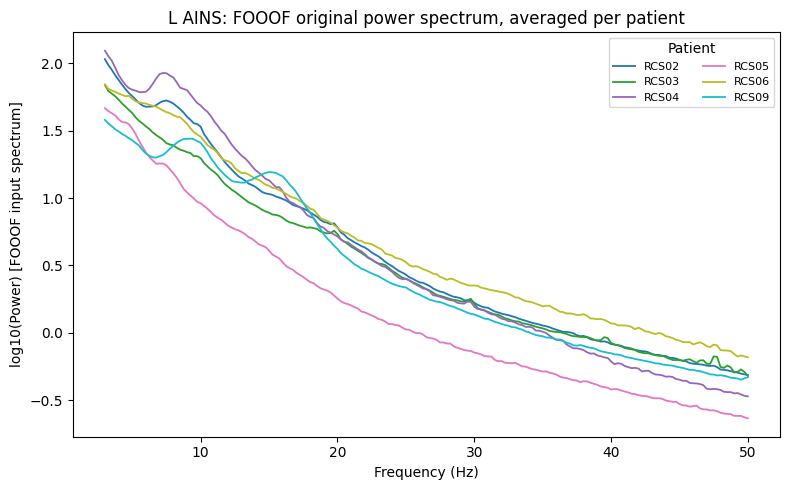

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. 取数据: 从fooof对象里拿freqs和原始power_spectrum(已经是log10 power了)
# =========================================================
subset = all_records_pd[all_records_pd['roi'] == 'L AINS'][['ptID', 'fooof']]

# 把每行fooof对象的power_spectrum展开成array,按patient求平均
subset = subset.copy()
subset['power_spectrum'] = subset['fooof'].apply(lambda fm: fm.power_spectrum)

subset_data = subset.groupby('ptID')['power_spectrum'].apply(
    lambda arrs: np.mean(np.vstack(arrs.values), axis=0)
)

# freqs假设跨行一致,直接取第一个fooof对象的
freqs_fooof = subset['fooof'].iloc[0].freqs

# =========================================================
# 2. 画图: 每个patient一个颜色, y轴直接是log10(power),不再重复取log
# =========================================================
ptIDs_in_subset = subset_data.index.tolist()
cmap = plt.cm.tab10(np.linspace(0, 1, len(ptIDs_in_subset)))
patient_color_map = dict(zip(ptIDs_in_subset, cmap))

fig, ax = plt.subplots(figsize=(8, 5))

for ptID in ptIDs_in_subset:
    power_mean = subset_data.loc[ptID]
    ax.plot(freqs_fooof, power_mean, color=patient_color_map[ptID],
            linewidth=1.3, label=ptID)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("log10(Power) [FOOOF input spectrum]")
ax.set_title("L AINS: FOOOF original power spectrum, averaged per patient")
ax.legend(title="Patient", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

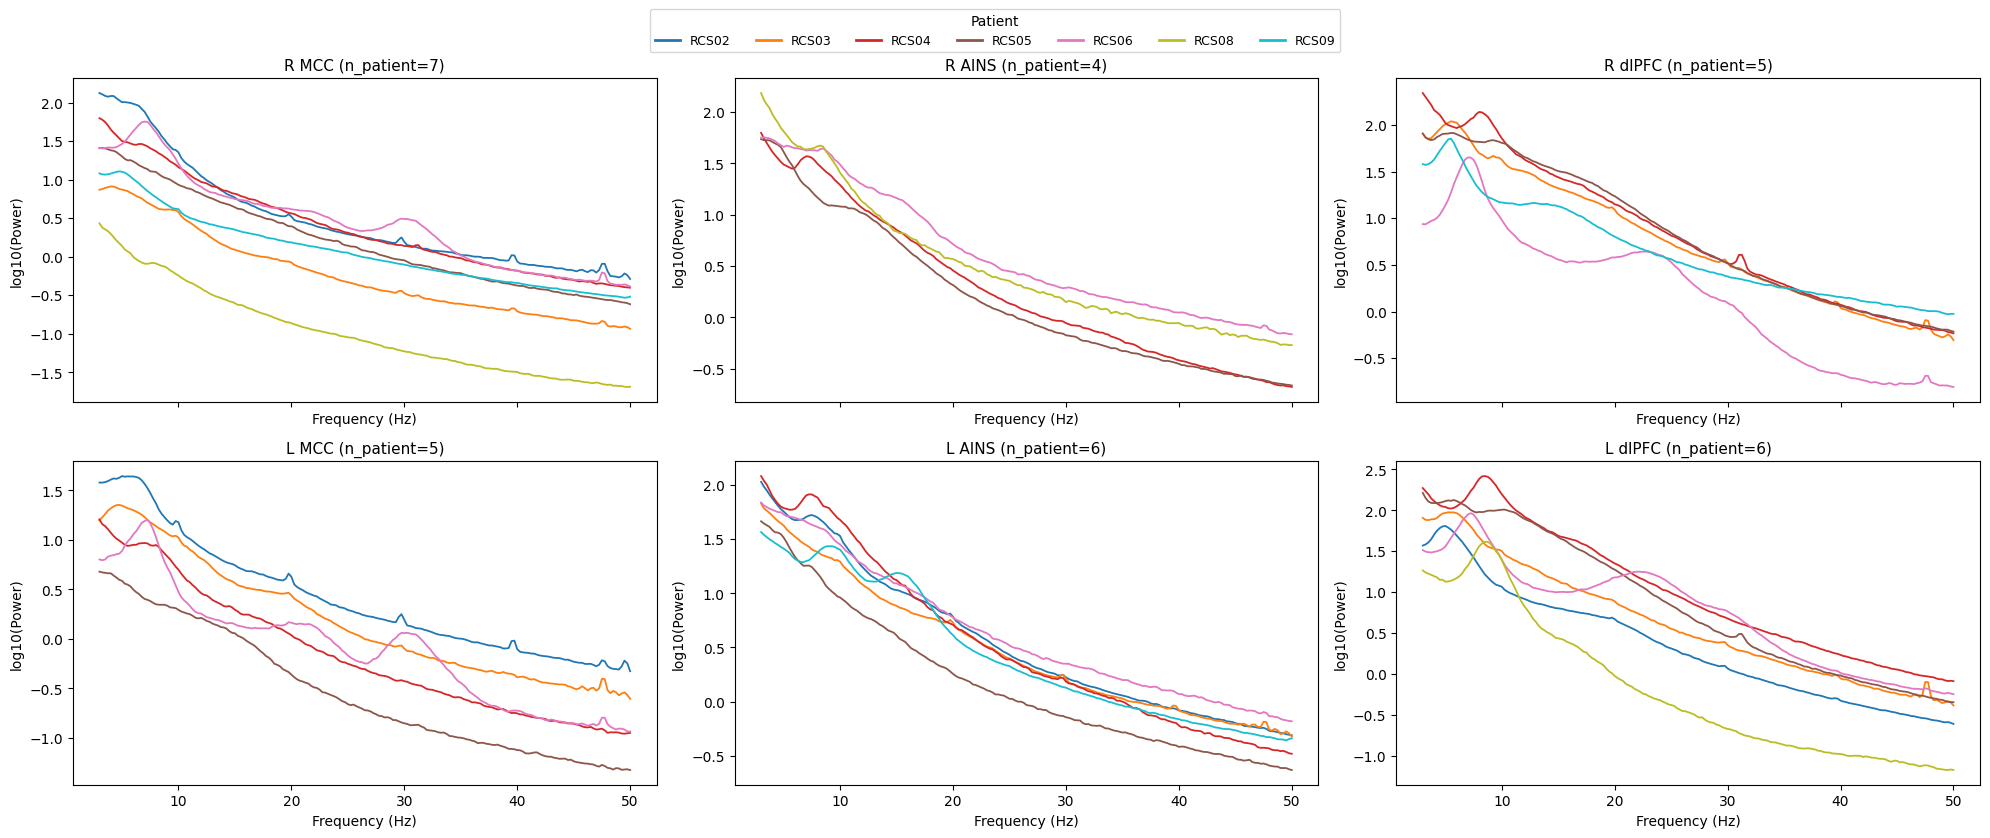

In [36]:
import numpy as np
import matplotlib.pyplot as plt

target_rois = ['R MCC', 'R AINS', 'R dlPFC', 'L MCC', 'L AINS', 'L dlPFC']
R2_THRESH = 0.9

# =========================================================
# 1. 统一patient颜色(跨subplot保持一致)
# =========================================================
all_ptIDs = sorted(all_records_pd['ptID'].unique())
cmap = plt.cm.tab10(np.linspace(0, 1, len(all_ptIDs)))
patient_color_map = dict(zip(all_ptIDs, cmap))

# =========================================================
# 2. 每个ROI一个subplot(不用sharey,避免某个roi的极端值把其他subplot压扁)
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharex=True, sharey=False)
axes_flat = axes.flatten()

for i, roi in enumerate(target_rois):
    ax = axes_flat[i]

    subset = all_records_pd[
        (all_records_pd['roi'] == roi) & (all_records_pd['r2'] >= R2_THRESH)
    ][['ptID', 'fooof']].copy()

    if len(subset) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_title(roi, fontsize=11)
        continue

    subset['power_spectrum'] = subset['fooof'].apply(lambda fm: fm.power_spectrum)

    subset_data = subset.groupby('ptID')['power_spectrum'].apply(
        lambda arrs: np.mean(np.vstack(arrs.values), axis=0)
    )

    freqs_fooof = subset['fooof'].iloc[0].freqs

    for ptID in subset_data.index:
        power_mean = subset_data.loc[ptID]
        ax.plot(freqs_fooof, power_mean, color=patient_color_map[ptID],
                 linewidth=1.3, label=ptID)

    ax.set_title(f"{roi} (n_patient={len(subset_data)})", fontsize=11)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("log10(Power)")

# =========================================================
# 3. 统一图例
# =========================================================
handles = [plt.Line2D([0], [0], color=patient_color_map[p], linewidth=2) for p in all_ptIDs]
fig.legend(handles, all_ptIDs, loc="upper center", ncol=len(all_ptIDs),
            bbox_to_anchor=(0.5, 1.05), title="Patient", fontsize=9)

plt.tight_layout()
plt.show()

ValueError: setting an array element with a sequence.

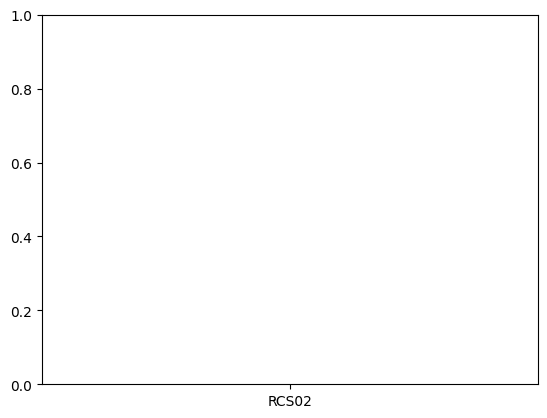

In [26]:
plt.plot(subset_data)

RCS02
RCS03


RCS04
RCS05
RCS06
RCS08
RCS09


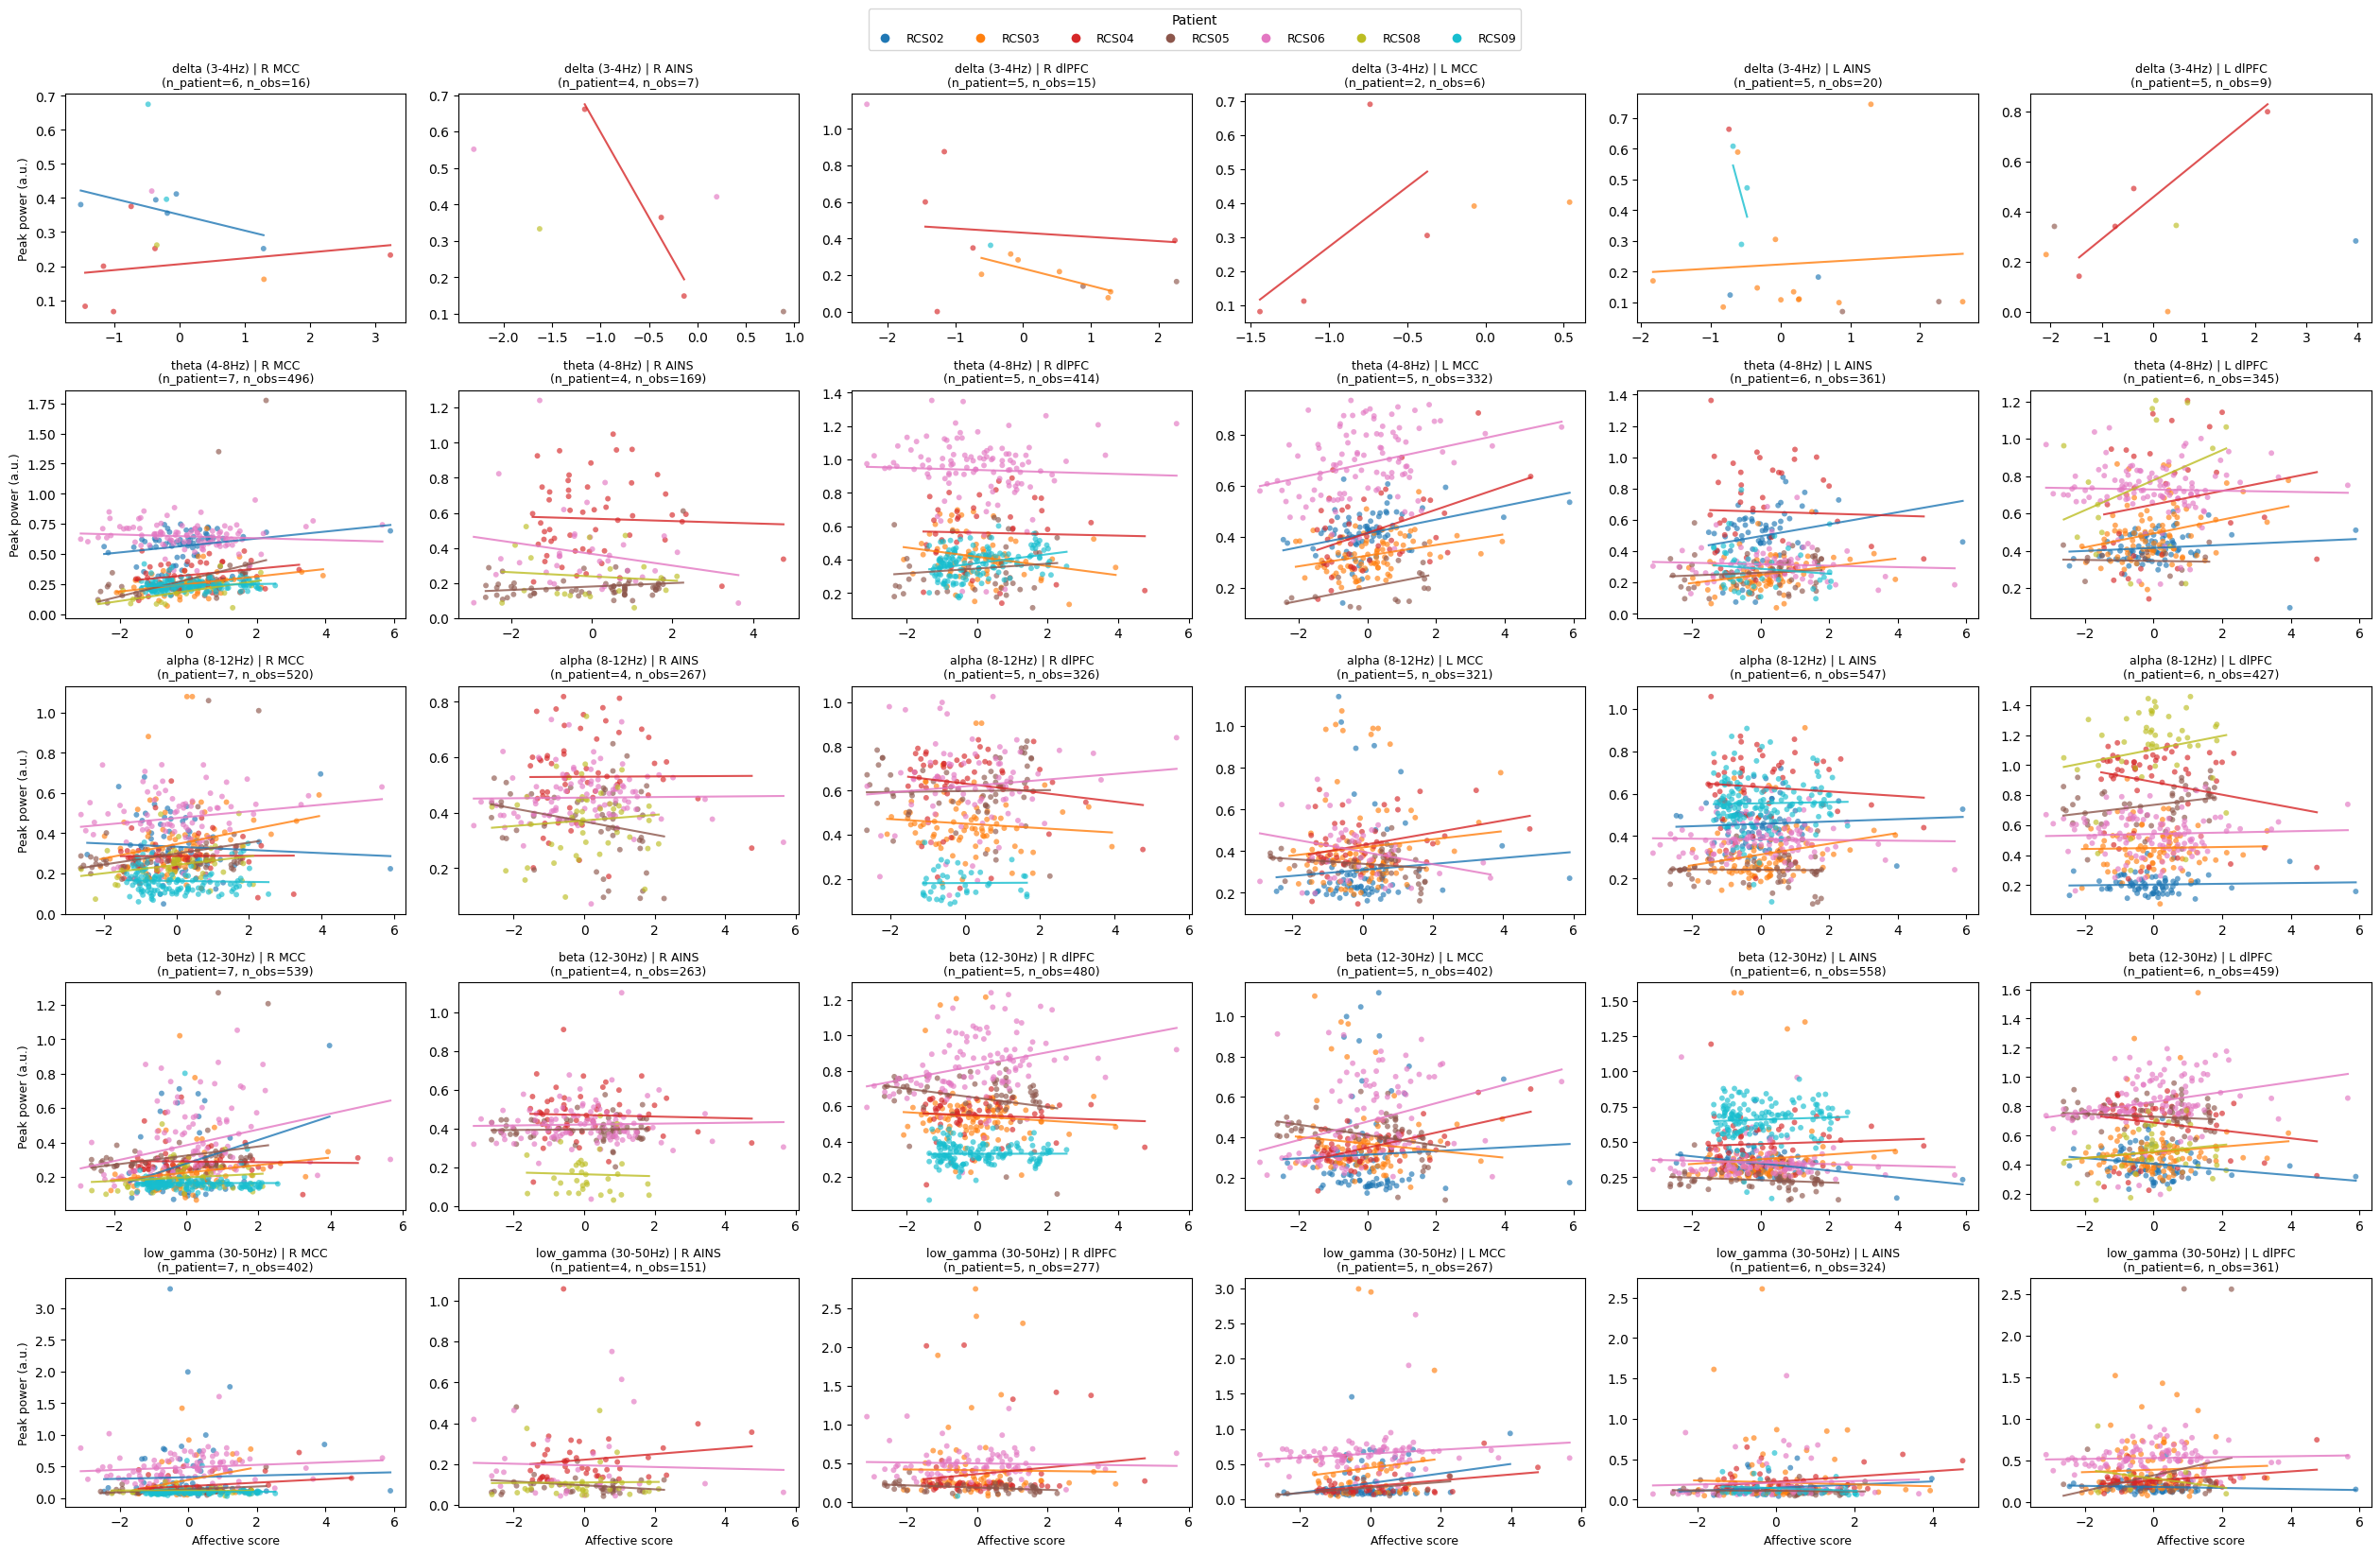

In [8]:
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS08', 'RCS09']
target_rois = ['R MCC', 'R AINS', 'R dlPFC', 'L MCC', 'L AINS','L dlPFC']

bandref = {
    'delta':     (3, 4),
    'theta':     (4, 8),
    'alpha':     (8, 12),
    'beta':      (12, 30),
    'low_gamma': (30, 50),
}
band_names = list(bandref.keys())
n_bands = len(band_names)

R2_THRESH = 0.9
DATA_DIR = "/userdata/jiahuang/pain-data/Stage1-test"

def extract_band_peak(fooof_obj, fmin, fmax):
    
    try:
        p = fooof_obj.get_params('peak_params')
        if p.ndim == 2:
            band_peaks = p[(p[:, 0] >= fmin) & (p[:, 0] <= fmax)]
            if len(band_peaks) > 0:
                idx = np.argmax(band_peaks[:, 1])
                return band_peaks[idx, 0], band_peaks[idx, 1]
        elif p.ndim == 1 and len(p) == 3 and fmin <= p[0] <= fmax:
            return p[0], p[1]
    except Exception:
        pass
    return np.nan, np.nan

def build_band_power_long_df(ptIDs=ptIDs, bandref=bandref, r2_thresh=R2_THRESH,
                                data_dir=DATA_DIR):
    all_rows = []

    for ptID in ptIDs:
        print(ptID)
        records_df = pd.read_pickle(f"{data_dir}/{ptID}/records_df_fooof_{ptID}.pkl")
        records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
        records_df['ptID'] = ptID

        sub = records_df[records_df['r2'] >= r2_thresh]

        for _, row in sub.iterrows():
            for band in band_names:
                fmin, fmax = bandref[band]
                cf, pw = extract_band_peak(row['fooof'], fmin, fmax)
                if np.isnan(pw):
                    continue  # 该band没检测到peak,跳过(不是0,是缺失)
                all_rows.append({
                    'ptID':      ptID,
                    'roi':       row['roi'],
                    'ch_label':  row['ch_label'],
                    'trial_idx': row['trial_idx'],
                    'band':      band,
                    'cf':        cf,
                    'pw':        pw,
                    'affective': row['affective'],
                    'sensory':   row['sensory'],
                })

    return pd.DataFrame(all_rows)

def average_across_electrodes(long_df):
    return long_df.groupby(['ptID', 'roi', 'band', 'trial_idx'], as_index=False).agg(
        pw=('pw', 'mean'),
        affective=('affective', 'first'),
        sensory=('sensory', 'first'),
    )

def plot_band_roi_grid(plot_df, target_rois=target_rois, band_names=band_names,
                         save_path="/mnt/user-data/outputs/band_roi_affective_power.png"):
    n_rois = len(target_rois)
    fig, axes = plt.subplots(n_bands, n_rois, figsize=(4.2 * n_rois, 3.2 * n_bands),
                               squeeze=False)

    cmap = plt.cm.tab10(np.linspace(0, 1, len(ptIDs)))
    patient_color_map = dict(zip(ptIDs, cmap))

    for i, band in enumerate(band_names):
        fmin, fmax = bandref[band]
        for j, roi in enumerate(target_rois):
            ax = axes[i][j]
            sub = plot_df[(plot_df['band'] == band) & (plot_df['roi'] == roi)]

            if sub.empty:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                         transform=ax.transAxes, fontsize=9, color="gray")
                ax.set_xticks([]); ax.set_yticks([])
            else:
                for ptID in ptIDs:
                    pt_sub = sub[sub['ptID'] == ptID]
                    if pt_sub.empty:
                        continue
                    ax.scatter(pt_sub['affective'], pt_sub['pw'],
                               color=patient_color_map[ptID], s=18, alpha=0.65,
                               edgecolors="none")

                    if len(pt_sub) >= 3 and pt_sub['affective'].nunique() > 1:
                        z = np.polyfit(pt_sub['affective'], pt_sub['pw'], 1)
                        xs = np.linspace(pt_sub['affective'].min(), pt_sub['affective'].max(), 50)
                        ax.plot(xs, np.polyval(z, xs), color=patient_color_map[ptID], linewidth=1.5, alpha=0.8)

                n_pt = sub['ptID'].nunique()
                ax.set_title(f"{band} ({fmin}-{fmax}Hz) | {roi}\n(n_patient={n_pt}, n_obs={len(sub)})",
                             fontsize=9)

            if i == n_bands - 1:
                ax.set_xlabel("Affective score", fontsize=9)
            if j == 0:
                ax.set_ylabel("Peak power (a.u.)", fontsize=9)

    handles = [plt.Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=patient_color_map[p], markersize=8) for p in ptIDs]
    fig.legend(handles, ptIDs, loc="upper center", ncol=len(ptIDs),
                bbox_to_anchor=(0.5, 1.03), title="Patient", fontsize=9)

    plt.tight_layout()
    # plt.savefig(save_path, dpi=200, bbox_inches="tight")
    # print(f"saved to {save_path}")


long_df = build_band_power_long_df()
plot_df = average_across_electrodes(long_df)
plot_band_roi_grid(plot_df)

In [49]:
# Function to extract numeric part from filename
from scipy.signal import decimate
def extract_number(filename):
    return int(''.join(filter(str.isdigit, filename)))

def append_reref_file(records_df, path_string, pt_path, file_keyword='reref', dataset_name='re-referenced',downsample_factor=2):
    record_app = records_df[['trial_idx','edf_ch_idx','ch_label','roi','affective','sensory']]
    record_app['reref'] = None
    record_app['reref'] = record_app['reref'].astype(object)
    # Get list of files in directory and sort them based on numeric part
    files = sorted(os.listdir(path_string), key=extract_number)
    
    for filename in files:
        if filename.endswith(rf'{file_keyword}.h5'):
            filepath = os.path.join(path_string, filename)
            # Load the .h5 file
            with h5py.File(filepath, 'r') as hf:
                # Load the dataset as float32
                dataset = np.array(hf[dataset_name], dtype=np.float32)
                dataset = decimate(dataset, q=downsample_factor, axis=0, zero_phase=True)
                # Append the dataset to the list
                mask = ((record_app['trial_idx']+1) == extract_number(filename[:-3]))
                for idx in record_app.index[mask]:
                    edf_ch_idx = record_app.at[idx, 'edf_ch_idx']
                    record_app.at[idx, 'reref'] = dataset[:, edf_ch_idx]

    return record_app


In [ ]:
ptID = 'RCS04'
path_string = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
pt_path = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
records_df_reref = append_reref_file(records_df,path_string,pt_path)

save_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_reref_{ptID}.csv"
records_df_reref.to_csv(save_path)

In [5]:
ptID = 'RCS04'
save_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_reref_{ptID}.csv"
records_df_reref = pd.read_csv(save_path, index_col=0)
records_df_reref

,trial_idx,edf_ch_idx,ch_label,roi,affective,sensory,reref
0,0,118,L ACC_1,L ACC,1.632835,2.15732,[ 60.529682 112.8403 110.24199 ... ...
1,0,113,L ACC_2,L ACC,1.632835,2.15732,[ -8.2260895 -14.029383 -11.992862 ... 34.4...
2,0,117,L ACC_3,L ACC,1.632835,2.15732,[-20.888613 -38.61233 -34.241104 ... 35.9591...
3,0,116,L ACC_4,L ACC,1.632835,2.15732,[-22.710192 -39.983707 -35.991566 ... -6.5...
4,0,114,L ACC_5,L ACC,1.632835,2.15732,[ 15.862535 29.286901 26.046415 ... -41.4537...
...,...,...,...,...,...,...,...
3016,82,37,R dlPFC_5,R dlPFC,0.400439,0.32594,[ 91.48797 170.4158 159.48087 ... -7.4...
3017,82,54,R dmPFC_1,R dmPFC,0.400439,0.32594,[ 18.510872 17.205364 43.981888 ... -82.9148...
3018,82,53,R dmPFC_2,R dmPFC,0.400439,0.32594,[ 28.120825 61.59562 59.58127 ... -16.3166...
3019,82,21,R dmPFC_3,R dmPFC,0.400439,0.32594,[ 19.65164 29.524689 22.530224 ... -23.7192...


In [62]:
col_ains = records_df_reref[(records_df_reref['ch_label']=='L AINS_1') & (records_df_reref['trial_idx']==1)]['reref'].values
col_acc = records_df_reref[(records_df_reref['ch_label']=='L ACC_1') & (records_df_reref['trial_idx']==1)]['reref'].values
data = pd.DataFrame({
    'L AINS_1': col_ains[0],
    'L ACC_1': col_acc[0]
})

In [55]:
from statsmodels.tsa.stattools import adfuller
signal = col_ains[0]
result = adfuller(signal)

print(result[1])   # p value

0.0


In [57]:
from statsmodels.tsa.stattools import kpss

stat, p, lags, crit = kpss(signal, regression='c')

print(stat)
print(p)

1.2494232540515167
0.01


/tmp/ipykernel_1069911/2659684686.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(signal, regression='c')


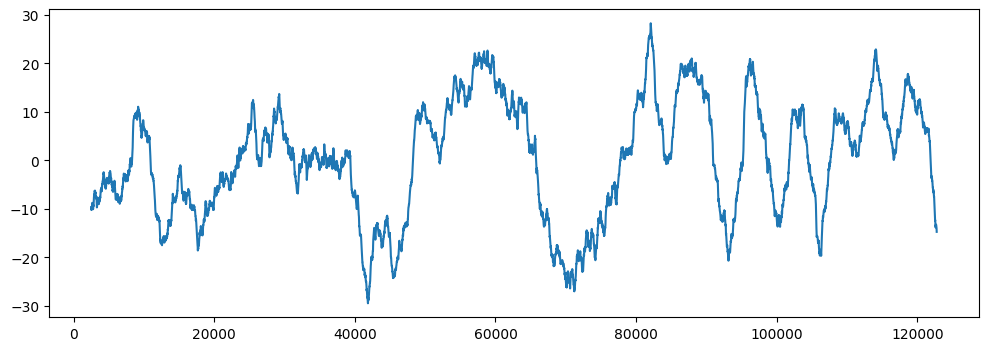

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

s = pd.Series(signal)

plt.figure(figsize=(12,4))
plt.plot(s.rolling(2500).mean())

In [63]:
from statsmodels.tsa.vector_ar.var_model import VAR

model = VAR(data)

results = model.select_order(30)

print(results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        15.30       15.30   4.413e+06       15.30
1        6.248       6.248       516.9       6.248
2        4.219       4.220       67.99       4.220
3        4.081       4.082       59.22       4.082
4        3.915       3.917       50.15       3.916
5        3.842       3.844       46.61       3.842
6        3.724       3.726       41.42       3.724
7        3.615       3.618       37.17       3.616
8        3.557       3.560       35.07       3.558
9        3.429       3.432       30.85       3.430
10       3.246       3.250       25.70       3.247
11       3.115       3.119       22.54       3.116
12       3.004       3.008       20.17       3.005
13       2.878       2.882       17.77       2.879
14       2.795       2.799       16.36       2.796
15       2.689       2.693       14.71       2.690
16       2.662       2.667     

In [66]:
lag = results.selected_orders['bic']

var_model = model.fit(lag)
print(var_model.is_stable())
gc = var_model.test_causality(
    caused='L AINS_1',
    causing='L ACC_1',
    kind='f'
)

print(gc.summary())

True
Granger causality F-test. H_0: L ACC_1 does not Granger-cause L AINS_1. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value      df     
--------------------------------------------------
         3.535          1.459   0.000 (30, 245334)
--------------------------------------------------


In [24]:
import os
import h5py
import numpy as np
import pandas as pd
ptID='RCS06'
# file = f"/userdata/rvatsyayan/AnushaData/Pain_Scores_{ptID}.xlsx"
# scores = pd.read_excel(file)

def extract_number(filename):
    return int(''.join(filter(str.isdigit, filename)))

pt_path_original = f"/userdata/rvatsyayan/AnushaData/HDF5 Pain Data/{ptID}"
pt_path = f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/biomarker/preproc_data/202605_newpreproc_all_channels/"
# files = sorted(os.listdir(pt_path), key=extract_number)

example_data = h5py.File(f"{pt_path}/10_reref.h5")
example_reref = np.array(example_data['re-referenced'])

example_data_original = h5py.File(f"{pt_path_original}/10.h5")
example_ieeg = np.array(example_data_original['ieeg_data'])
example_electrode = pd.DataFrame(example_data_original['electrode_properties'])
# example_meta = pd.DataFrame(example_data['meta/edfinfo_json'])
# example_pain = np.array(example_data['pain_info'])
example_f = np.array(example_data_original['frequency'])

In [27]:
example_electrode.loc[0]

0        b'3'
1        b'4'
2        b'5'
3        b'6'
4        b'7'
        ...  
103    b'126'
104    b'127'
105    b'128'
106    b'129'
107    b'130'
Name: 0, Length: 108, dtype: object